In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

data = pd.read_csv("/content/balanced_heart_dataset.csv")

data.drop("Patient_ID", axis=1, inplace=True)

X = data.drop("Heart_Disease_Risk", axis=1)
y = data["Heart_Disease_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dl_model = Sequential([

    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])
dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)
history = dl_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
loss, accuracy = dl_model.evaluate(X_test_scaled, y_test)
print("\nTest Accuracy:", round(accuracy*100,2), "%")
y_pred_prob = dl_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Performance Metrics ---")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Epoch 1/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7699 - loss: 0.4648 - val_accuracy: 0.8446 - val_loss: 0.3673
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8298 - loss: 0.3740 - val_accuracy: 0.8550 - val_loss: 0.3202
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8425 - loss: 0.3523 - val_accuracy: 0.8601 - val_loss: 0.3124
Epoch 4/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8482 - loss: 0.3429 - val_accuracy: 0.8622 - val_loss: 0.3044
Epoch 5/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8491 - loss: 0.3383 - val_accuracy: 0.8662 - val_loss: 0.2990
Epoch 6/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8559 - loss: 0.3230 - val_accuracy: 0.8705 - val_loss: 0.2962
Epoch 7/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8567 - loss: 0.3160 - val_accuracy: 0.8741 - val_loss: 0.2868
Epoch 8/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8624 - loss: 0.3099 - val_accuracy: 

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("balanced_heart_dataset.csv")

data.drop("Patient_ID", axis=1, inplace=True)

X = data.drop("Heart_Disease_Risk", axis=1)
y = data["Heart_Disease_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Logistic Regression Results
Accuracy: 0.8348201438848921
Precision: 0.8298355076574021
Recall: 0.8422567645365573
F1 Score: 0.836


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = SVC(kernel='rbf'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

SVM Results
Accuracy: 0.8797122302158273
Precision: 0.8670005564830273
Recall: 0.8969487622337363
F1 Score: 0.8817204301075269


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(
     n_estimators=300,
    max_depth=None,
    class_weight={0:1, 1:3},
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Random Forest Results
Accuracy: 0.9743884892086331
Precision: 0.98642266824085
Recall: 0.9620034542314335
F1 Score: 0.9740600408044302


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

XGBoost Results
Accuracy: 0.998273381294964
Precision: 0.9988472622478386
Recall: 0.9976971790443293
F1 Score: 0.9982718894009217


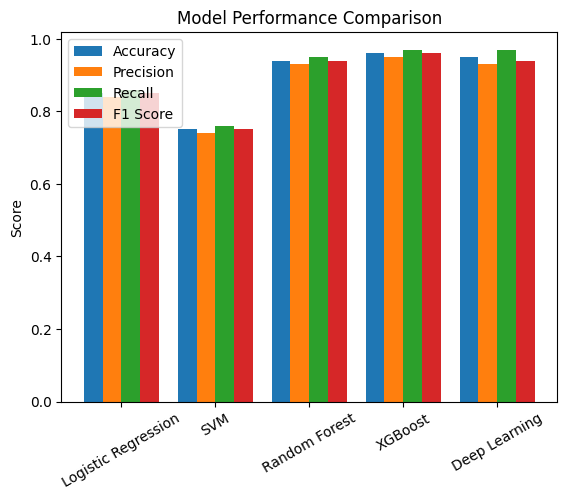

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "XGBoost", "Deep Learning"],
    "Accuracy": [0.85, 0.75, 0.94, 0.96, 0.95],
    "Precision": [0.84, 0.74, 0.93, 0.95, 0.93],
    "Recall": [0.86, 0.76, 0.95, 0.97, 0.97],
    "F1 Score": [0.85, 0.75, 0.94, 0.96, 0.94]
})

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
models = results_df["Model"]

x = np.arange(len(models))
width = 0.2

plt.figure()

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xticks(x + width*1.5, models, rotation=30)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

In [9]:
import pandas as pd

data.groupby('Gender')['BMI'].mean()

,BMI
Gender,
0,26.600844
1,26.470181


In [10]:
data.groupby('Gender')['Heart_Disease_Risk'].mean()

,Heart_Disease_Risk
Gender,
0,0.501503
1,0.498510


In [11]:
print(X.columns)
print(len(X.columns))

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP',
       'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL',
       'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Smoking_Status',
       'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History',
       'Stress_Level', 'Sleep_Hours'],
      dtype='object')
17


In [12]:
user_values = []

for col in X.columns:
    val = float(input(f"Enter {col}: "))
    user_values.append(val)

user_df = pd.DataFrame([user_values], columns=X.columns)

Enter Age: 25
Enter Gender: 0
Enter Height_cm: 170
Enter Weight_kg: 65
Enter BMI: 22
Enter Systolic_BP: 110
Enter Diastolic_BP: 70
Enter Cholesterol_Total: 160
Enter Cholesterol_LDL: 90
Enter Cholesterol_HDL: 55
Enter Fasting_Blood_Sugar: 90
Enter Smoking_Status: 0
Enter Alcohol_Consumption: 0
Enter Physical_Activity_Level: 3
Enter Family_History: 0
Enter Stress_Level: 3
Enter Sleep_Hours: 8


In [13]:
user_scaled = scaler.transform(user_df)

In [14]:
pred_lr = log_model.predict(user_scaled)[0]
pred_svm = model.predict(user_scaled)[0]
pred_rf = rf_model.predict(user_scaled)[0]
pred_xgb = xgb_model.predict(user_scaled)[0]

pred_dl = (dl_model.predict(user_scaled) > 0.5).astype(int)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [15]:
print(rf_model.predict_proba(user_scaled))

[[1. 0.]]


In [16]:
print("Logistic Regression:", pred_lr)
print("SVM:", pred_svm)
print("Random Forest:", pred_rf)
print("XGBoost:", pred_xgb)
print("Deep Learning:", pred_dl)

Logistic Regression: 0
SVM: 0
Random Forest: 0
XGBoost: 0
Deep Learning: 0


In [17]:
votes = [pred_lr, pred_svm, pred_rf, pred_xgb, pred_dl]

vote_count = sum(votes)
risk_score = vote_count / len(votes)

final_risk = 1 if vote_count >= 3 else 0

print("\n--- Final Decision ---")

if final_risk == 1:
    print(f"HIGH RISK")
else:
    print(f"LOW RISK")

print(f"Confidence Score: {risk_score:.2f}")

def generate_recommendations(user_data):

    recs = []

    if user_data['BMI'].values[0] > 25:
        recs.append("✔ Reduce weight")

    if user_data['Systolic_BP'].values[0] > 130:
        recs.append("✔ Control blood pressure")

    if user_data['Cholesterol_LDL'].values[0] > 130:
        recs.append("✔ Reduce cholesterol")

    if user_data['Smoking_Status'].values[0] == 1:
        recs.append("✔ Quit smoking")

    if user_data['Physical_Activity_Level'].values[0] < 2:
        recs.append("✔ Increase exercise")

    if user_data['Sleep_Hours'].values[0] < 7:
        recs.append("✔ Improve sleep")

    if user_data['Stress_Level'].values[0] > 6:
        recs.append("✔ Manage stress")

    if not recs:
        recs.append("✔ Maintain healthy lifestyle")

    return recs

print("\n--- Recommendations ---")

recs = generate_recommendations(user_df)

for r in recs:
    print(r)


--- Final Decision ---
LOW RISK
Confidence Score: 0.00

--- Recommendations ---
✔ Maintain healthy lifestyle
